# 🌍 Search & Load CMIP6 Data via ESGF / OPeNDAP

This notebook searches for and loads CMIP6 climate model output directly over the network using
[**Earth System Grid Federation**](https://esgf.llnl.gov/) (ESGF) infrastructure — the backbone of the CMIP6 distribution system.

## 📋 Prerequisites
<div align="left">

| Topic | Where to learn |
|---|---|
| Python basics | any intro Python course |
| xarray fundamentals | [xarray tutorial](https://tutorial.xarray.dev) |
| What CMIP6 is | [Eyring et al. 2016](https://doi.org/10.5194/gmd-9-1937-2016) |
| Lazy evaluation / Dask | [Dask best practices](https://docs.dask.org/en/stable/best-practices.html) |
</div>


Two technologies do the heavy lifting:

| Technology | Role |
|---|---|
| [**esgf-pyclient**](https://esgf-pyclient.readthedocs.io/en/latest/) | Discover *which* files hold the data we want, searching federally across all ESGF nodes |
| [**OPeNDAP**](https://www.opendap.org/) | Stream those files lazily over HTTP — no full download |

**What we'll do**

1. Query ESGF for daily near-surface air temperature (`tas`) under the **SSP5-8.5** scenario
2. Open the remote files lazily with `xarray` + `dask`
3. Map the temperature field on a proper geographic projection
4. Build an **area-weighted global-mean** temperature series
5. Compute the **warming trend** over the 21st century projection period

> ⚠️ **Live data.** Cells pull from ESGF nodes in real time. If a search or load cell errors, it is almost always a node being temporarily down — re-run, or try a different `source_id` from the search results.

## ⚙️ Setup

Imports plus a little plot styling so the figures look clean.

In [1]:
import os

os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "1"

import pandas as pd
import xarray as xr
from pyesgf.search import SearchConnection

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# --- light, consistent plot styling ---
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 11,
})

## 🔎 Search using esgf-pyclient

[`pyesgf.search.SearchConnection`](https://esgf-pyclient.readthedocs.io/en/latest/api.html)
is the entry point for querying the ESGF catalogue. We point it at the **DKRZ** node and set
`distrib=True` so the search is federated across **all ESGF nodes** (not just the one we connect to).
The search context and OPeNDAP URL extraction happen in the cells below.



In [2]:
esgf_node = "http://esgf-data.dkrz.de/esg-search"
conn = SearchConnection(esgf_node, distrib=True)

## 🔍 Define the Search Context

`conn.new_context(...)` builds a **query filter** against the ESGF catalogue. Each keyword argument is a **facet** — a controlled vocabulary term that narrows the search. Only datasets matching *all* specified facets are returned.

| Parameter | Value used | Meaning |
|---|---|---|
| `project` | `"CMIP6"` | The overarching model intercomparison project. ESGF hosts data from CMIP5, CMIP6, CORDEX, and others; this pins us to CMIP6. |
| `experiment_id` | `"ssp585"` | The **Shared Socioeconomic Pathway** scenario. SSP5-8.5 is the high-emissions "fossil-fuelled development" pathway, reaching ~8.5 W m⁻² radiative forcing by 2100 — the upper end of the scenario range. |
| `frequency` | `"day"` | Temporal resolution of the output files. Common options are `"mon"` (monthly), `"day"` (daily), `"6hr"`, `"3hr"`. Daily data gives enough resolution to study extremes. |
| `member_id` | `"r1i1p1f1"` | The **ensemble member label**, encoding four indices: **r**ealization · **i**nitialization · **p**hysics · **f**orcing. `r1i1p1f1` is the standard first member, present in virtually every CMIP6 model — a safe default for multi-model comparisons. |
| `variable_id` | `"tas"` | The CF-convention short name for **near-surface air temperature** (typically at 2 m height). Defined in the CMIP6 data request; other common variables include `"pr"` (precipitation), `"psl"` (sea-level pressure), `"tos"` (sea-surface temperature). |
| `grid_label` | `"gr"` | The grid type. `"gr"` means the model's own **regridded** output (interpolated to a standard lat/lon grid by the modelling centre). The alternative `"gn"` is the model's **native** (possibly irregular) grid. `"gr"` is generally easier to work with across models. |
| `latest` | `True` | Return only the **most recent version** of each dataset. ESGF datasets are versioned (e.g. `v20200317`); setting this to `True` avoids accidentally loading superseded or retracted data. |
| `facets` | `"*"` | Ask the server to return **all available metadata facets** in the search response (model name, institution, version, etc.). Required so the results contain enough information to build the summary table in the next cell. |

Search for **daily** near-surface air temperature (`tas`) under the **SSP5-8.5** high-emissions scenario (`ssp585`), ensemble member `r1i1p1f1`, regridded grid (`gr`). The federated search (`distrib=True`) returns files from all ESGF mirror nodes; results are grouped by model in the next cell.

In [3]:
ctx = conn.new_context(
    project="CMIP6",
    experiment_id="ssp585",
    frequency="day",
    member_id="r1i1p1f1",
    variable_id="tas",
    grid_label="gr",
    latest=True,
    facets="*"
)

datasets = ctx.search()
print(f"Found {len(datasets)} datasets.\n")


Found 10 datasets.



In [4]:
def _v(meta, key):
    v = meta.get(key)
    return v[0] if isinstance(v, list) and v else v

rows = []
for ds in datasets:
    m = ds.json
    urls = [
        f.opendap_url for f in ds.file_context().search() if f.opendap_url
    ]
    if urls:
        rows.append({
            'activity_id':    _v(m, 'activity_id'),
            'institution_id': _v(m, 'institution_id'),
            'source_id':      _v(m, 'source_id'),
            'experiment_id':  _v(m, 'experiment_id'),
            'member_id':      _v(m, 'member_id'),
            'table_id':       _v(m, 'table_id'),
            'variable_id':    _v(m, 'variable_id'),
            'grid_label':     _v(m, 'grid_label'),
            'version':        _v(m, 'version'),
            'opendap_url':    urls,
        })

models = pd.DataFrame(rows)
models

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,version,opendap_url
0,ScenarioMIP,NIMS-KMA,KACE-1-0-G,ssp585,r1i1p1f1,day,tas,gr,20200317,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
1,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,day,tas,gr,20200310,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
2,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,day,tas,gr,20210113,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
3,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,day,tas,gr,20201201,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
4,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmi...
5,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[http://vesg.ipsl.upmc.fr/thredds/dodsC/cmip6/...
6,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,day,tas,gr,20190903,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
7,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,day,tas,gr,20200310,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
8,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,day,tas,gr,20210113,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...
9,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,day,tas,gr,20201201,[http://esgf3.dkrz.de/thredds/dodsC/cmip6/Scen...


## 📦 Load data with Xarray

The DataFrame above has one row per model. The `opendap_url` column holds a **list** of all file URLs
for that dataset — one URL per time-chunk file. We pick `models.iloc[0]` (KACE-1-0-G) and open all its OPeNDAP URLs at once with
`xr.open_mfdataset`. Change the index to load a different model from the table
(e.g. `models.iloc[2]` for EC-Earth3-CC).

> ⚠️ If you get a **403 error**, the node hosting that model's files is down. Simply pick a different
> row index — rows 0–3 all use the CEDA mirror (`esgf.ceda.ac.uk`), which tends to be the most stable.

In [ ]:
model = models.iloc[0]

ds = xr.open_mfdataset(
    model.opendap_url,
    combine="by_coords",
    chunks={},
    engine="pydap",
)
ds

c:\Users\nikol\Desktop\Desirmed\Workshops\Summerschool\desirmed_summerschool\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nikol\Desktop\Desirmed\Workshops\Summerschool\desirmed_summerschool\.venv\Lib\site-packages\pydap\handlers\dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 30960, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 495kB dask.array<chunksize=(30960, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(30960, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                Hyun Min, Sung (sunghm122@korea.kr)
    ...                     ...
    tracking_id:            hdl:21.14100/b5ca95fb-94dc-425c-81d6-7f29824a7fa5
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by NIMS-KMA is licensed...
    cmor_version:           3.4.0
    Unlimited_Dimension:    time

In [6]:
ds.tas

<xarray.DataArray 'tas' (time: 30960, lat: 144, lon: 192)> Size: 3GB
dask.array<open_dataset-tas, shape=(30960, 144, 192), dtype=float32, chunksize=(30960, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    original_name:  m01s03i236
    cell_methods:   area: time: mean (interval: 1 day)
    cell_measures:  area: areacella
    history:        2020-03-17T04:05:18Z altered by CMOR: Treated scalar dime...
    _ChunkSizes:    [1, 144, 192]

## 🗺️ Map a single day

Instead of a bare lat/lon grid, we render the field on a **Robinson projection** with coastlines
and a labelled colorbar. SSP5-8.5 data starts in 2015, so we pick a date within that range.

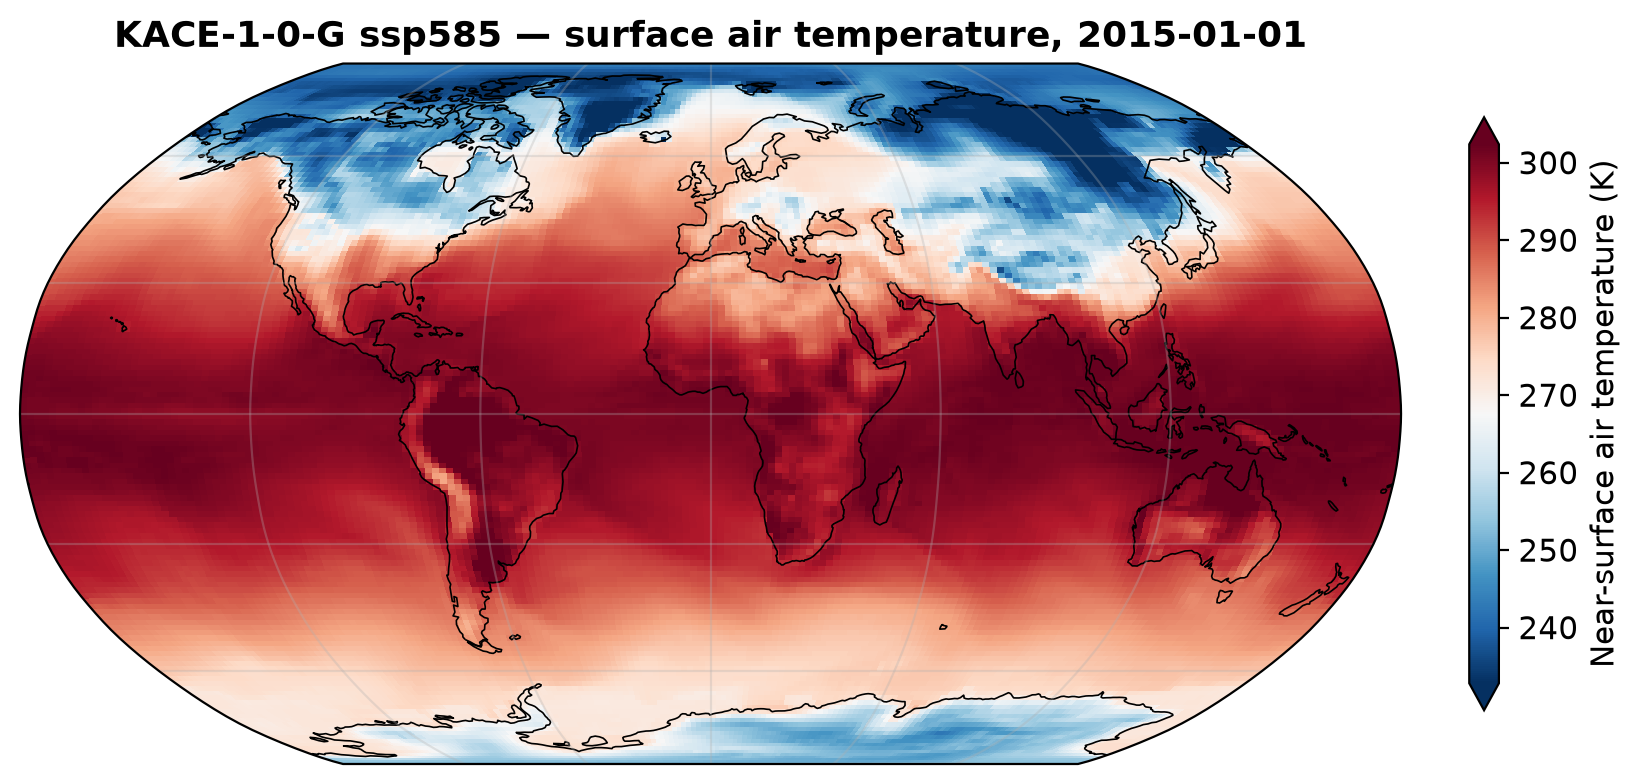

In [7]:
snapshot = ds.tas.isel(time=0).squeeze()
date_str = str(snapshot.time.values)[:10]

fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.Robinson())

p = snapshot.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', robust=True,
    cbar_kwargs={'label': 'Near-surface air temperature (K)', 'shrink': 0.7, 'pad': 0.04},
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(alpha=0.3)
ax.set_global()
ax.set_title(f'{model["source_id"]} {model["experiment_id"]} — surface air temperature, {date_str}', fontweight='bold')
plt.show()

### 📍 Time series at a specific location

Instead of a global mean, extract the temperature at a single grid point using `.sel()` with
`method='nearest'` — xarray snaps to the closest grid cell to your target coordinates.

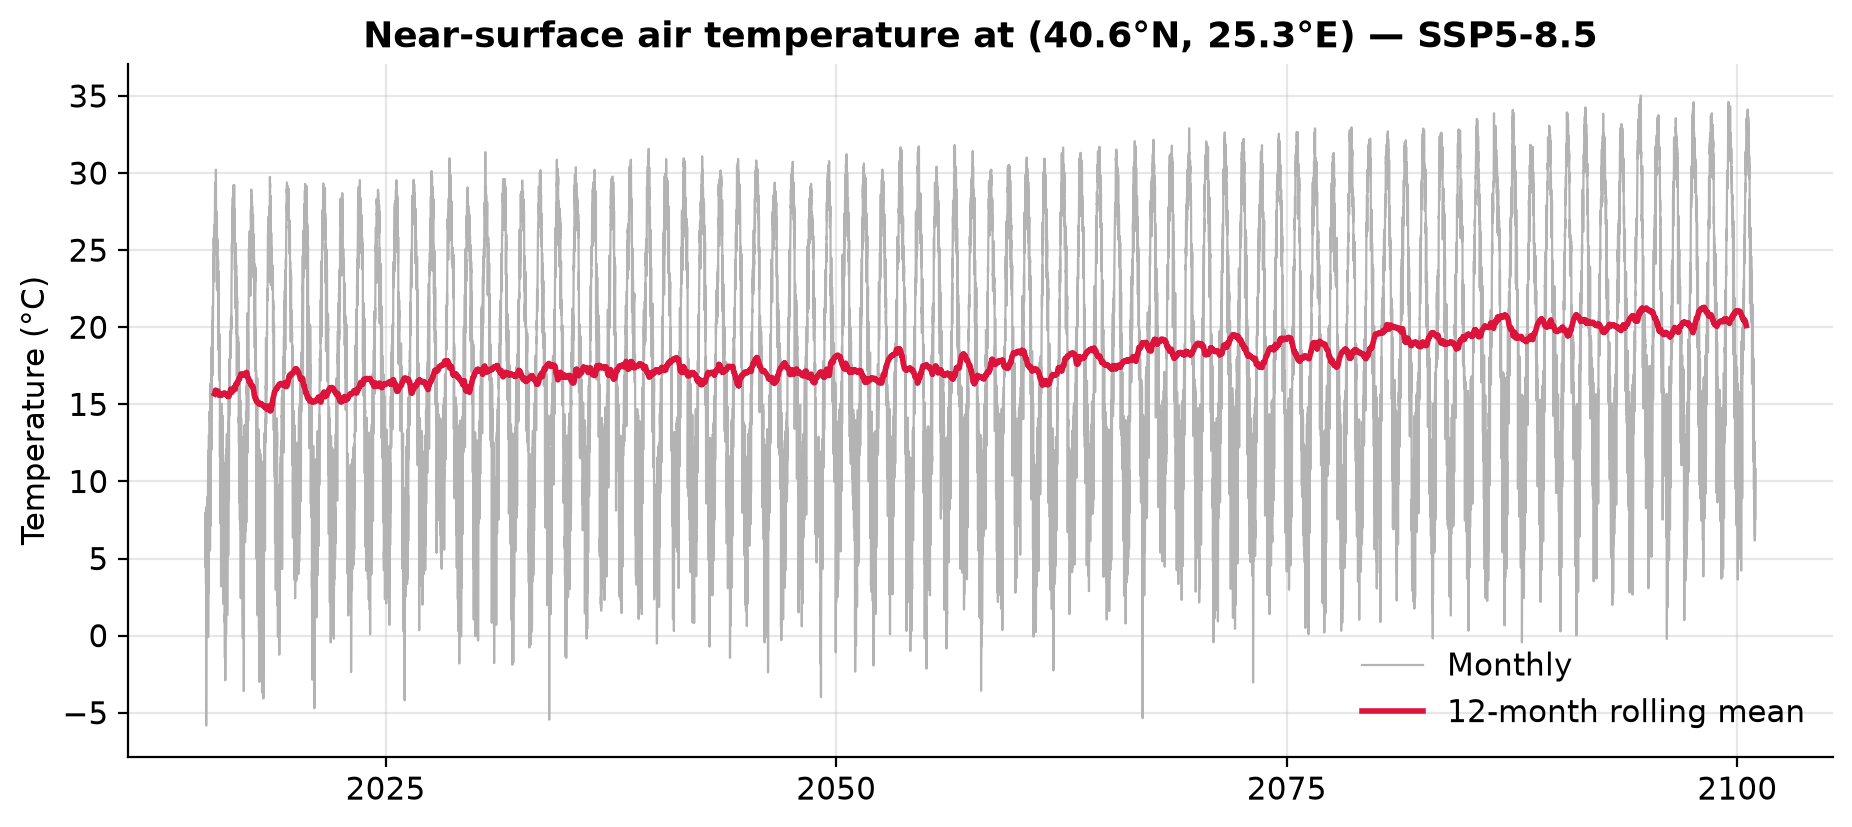

In [ ]:
# Target location — change to any lat/lon you like
target_lat = 41.133  # Xanthi, Greece
target_lon = 24.883

point = ds.tas.sel(lat=target_lat, lon=target_lon, method="nearest")

point_C = point - 273.15  # convert from K to °C


fig, ax = plt.subplots(figsize=(11, 4.5))
point_C.plot(ax=ax, color="0.7", lw=0.8, label="Monthly")
point_C.rolling(time=365, center=True).mean().plot(
    ax=ax, color="crimson", lw=2, label="12-month rolling mean"
)

actual_lat = float(point.lat)
actual_lon = float(point.lon)
ax.set_title(
    f"Near-surface air temperature at ({actual_lat:.1f}°N, {actual_lon:.1f}°E) — SSP5-8.5",
    fontweight="bold",
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.show()


---
## Summary

We used **esgf-pyclient** to search for CMIP6 `tas` output across all federated ESGF nodes,
loaded the first available model's SSP5-8.5 files lazily over OPeNDAP with `xarray` + `dask`,
mapped them on geographic projections, and extracted a local temperature time series.

Work through the **exercises below** to put these ideas into practice.

---
## 🎓 Exercises

Work through these exercises in order — each one builds on the previous. Solutions are intentionally **not** provided; use the cells above as templates.

> **Tip:** If a node is down, switch to a different `models.iloc[N]` row rather than waiting for it to recover.

### Exercise 1 — Explore the dataset structure ⭐

Before doing any analysis it is always good practice to understand what you have loaded.

**Tasks:**
1. Print the number of latitude points, longitude points, and time steps in `ds`.
2. What are the start and end dates of the time axis? (Hint: use `ds.time.values[0]` and `ds.time.values[-1]`.)
3. What is the spatial resolution in degrees? (Divide 180° by the number of latitude points.)
4. What unit is `tas` stored in? Find this in the variable attributes.

*These are all metadata lookups — no data is actually downloaded.*

In [ ]:
# Exercise 1 — your code here

# 1. Dimensions
print("Time steps :", ds.dims["time"])
print("Latitudes  :", ds.dims["lat"])
print("Longitudes :", ds.dims["lon"])

# 2. Time range
# YOUR CODE HERE

# 3. Spatial resolution
# YOUR CODE HERE

# 4. Units
# YOUR CODE HERE

### Exercise 2 — Map a different season ⭐⭐

The snapshot above used `isel(time=0)`, which is the first day of January 2015.

**Tasks:**
1. Select a day in **July 2015** instead (hint: use `ds.tas.sel(time="2015-07-15", method="nearest")`).
2. Plot it on a Robinson projection with the same colormap and coastlines as the example.
3. Compare the two maps visually: where are the biggest differences between January and July? Why?

*Think about which hemisphere has summer in July and how that affects the temperature pattern.*

In [ ]:
# Exercise 2 — your code here
import cftime

# 1. Select a July snapshot
# The model uses a 360-day calendar (cftime.Datetime360Day), so we must pass
# a cftime object rather than a plain string when using method="nearest".
july_snapshot = ds.tas.sel(time=cftime.Datetime360Day(2015, 7, 15), method="nearest").squeeze()

# 2. Plot on Robinson projection
# YOUR CODE HERE (copy and adapt the map cell above)


### Exercise 3 — Temperature at your location ⭐⭐

The example showed a time series for Xanthi, Greece.

**Tasks:**
1. Pick a city of your choice anywhere in the world. Look up its latitude and longitude.
2. Extract the temperature time series at that location using `.sel(lat=..., lon=..., method="nearest")`.
3. Convert from Kelvin to Celsius and plot the daily values plus a 1-year rolling mean.
4. What warming do you expect to see by 2100 relative to 2015 at your chosen location?

*Check which grid cell xarray actually snapped to by printing `point.lat.values` and `point.lon.values`.*

In [ ]:
# Exercise 3 — your code here

# 1. Choose a city
my_lat = ???   # replace with your city's latitude
my_lon = ???   # replace with your city's longitude

# 2. Extract the nearest grid point
my_point = ds.tas.sel(lat=my_lat, lon=my_lon, method="nearest")
print(f"Snapped to: lat={float(my_point.lat):.2f}, lon={float(my_point.lon):.2f}")

# 3. Convert to Celsius and plot
my_point_C = my_point - 273.15
# YOUR CODE HERE

### Exercise 4 — Annual mean warming signal ⭐⭐⭐

Daily data is noisy. Resampling to annual means reveals the long-term trend more clearly.

**Tasks:**
1. Use `.resample(time="YE").mean()` on `ds.tas` to compute **annual mean** temperature for every grid cell.
2. Extract the annual mean time series at your chosen city (from Exercise 3) and convert to Celsius.
3. Plot the annual means as a bar chart or line plot.
4. **Estimate the warming**: compute the difference between the mean temperature of the last decade (2090–2100) and the first decade (2015–2025).

*`resample` works like `groupby` for time — it aggregates all days within each year.*

```python
# Hint for step 1
tas_annual = ds.tas.resample(time="YE").mean()

# Hint for step 4
early = tas_annual.sel(time=slice("2015", "2025")).mean("time")
late  = tas_annual.sel(time=slice("2090", "2100")).mean("time")
warming = late - early
```

In [ ]:
# Exercise 4 — your code here

# 1. Annual mean over all grid cells
tas_annual = ds.tas.resample(time="YE").mean()

# 2. Extract your city's annual series and convert to Celsius
# YOUR CODE HERE

# 3. Plot the annual means
# YOUR CODE HERE

# 4. Compute warming between first and last decade
# YOUR CODE HERE
# print(f"Projected warming: {float(warming):.2f} °C")

### Exercise 5 — Load a different model ⭐⭐⭐

So far we have only used `models.iloc[0]` (KACE-1-0-G). Different climate models produce different projections.

**Tasks:**
1. Load a second model from the `models` DataFrame (e.g. `models.iloc[1]` for EC-Earth3).
2. Extract the annual mean time series at Xanthi or your chosen city for **both** models.
3. Plot both time series on the same axes in different colours.
4. Are the two models in good agreement? Where do they diverge the most?

*Comparing multiple models is the first step toward understanding model uncertainty — a core concept in climate science.*

In [ ]:
# Exercise 5 — your code here

# 1. Load a second model
model2 = models.iloc[1]   # EC-Earth3; change if this node is down
ds2 = xr.open_mfdataset(
    model2.opendap_url,
    combine="by_coords",
    chunks={},
    engine="pydap",
)

# 2. Annual mean at your location for both models
# YOUR CODE HERE

# 3. Plot on the same axes
fig, ax = plt.subplots(figsize=(11, 4.5))
# YOUR CODE HERE
# Example:
# series1.plot(ax=ax, label=model["source_id"])
# series2.plot(ax=ax, label=model2["source_id"])
ax.legend(frameon=False)
plt.show()

### Exercise 6 (Bonus) — Search for a different variable ⭐⭐⭐⭐

Temperature (`tas`) is just one of hundreds of CMIP6 variables. Repeat the full search-and-load workflow for **precipitation** (`pr`).

**Tasks:**
1. Run a new ESGF search with `variable_id="pr"` (keep the same experiment, frequency, and member).
2. Load one model's files with `xr.open_mfdataset`.
3. Check the units in `ds_pr.pr.attrs["units"]` — CMIP6 stores precipitation in **kg m⁻² s⁻¹** (i.e. mm/s). Multiply by 86400 to convert to **mm/day**.
4. Plot a global map of annual mean precipitation (hint: take the time mean first with `.mean("time")`).

*Precipitation projections are much more uncertain than temperature — what pattern do you notice?*

```python
# Unit conversion hint
pr_mm_day = ds_pr.pr * 86400
pr_mm_day.attrs["units"] = "mm day⁻¹"
```

In [ ]:
# Exercise 6 — your code here

# 1. Search for precipitation
ctx_pr = conn.new_context(
    project="CMIP6",
    experiment_id="ssp585",
    frequency="day",
    member_id="r1i1p1f1",
    variable_id="pr",          # <-- changed
    grid_label="gr",
    latest=True,
    facets="*"
)
datasets_pr = ctx_pr.search()
print(f"Found {len(datasets_pr)} precipitation datasets.")

# 2. Build a models DataFrame (reuse the same pattern as above)
# YOUR CODE HERE

# 3. Load the first model
# YOUR CODE HERE

# 4. Convert units and plot a global mean map
# YOUR CODE HERE